# Ingredient Scanner: Person 2 (Deep Learning NER) and Person 3 (OCR, knowledge base, app)

This notebook continues `ingredient_scanner_person1_pipeline.ipynb`, which built the data foundation.
Here we:
- train and compare NER models (dictionary rules, CRF, DistilBERT, DistilBERT with OCR-noise augmentation, DistilBERT + CRF, BERT-base);
- build the OCR pipeline, knowledge base and entity linking;
- connect everything into the photo-to-result app.

```
PACKET IMAGE → OCR (EasyOCR) → code clean-up → INGREDIENTS SECTION → NORMALISATION
→ NER (DistilBERT) → ENTITY LINKING (knowledge base) → CATEGORY SUMMARY → USER-FRIENDLY RESULT
```

**Honesty note.**
- All models are trained on **silver** (rule-made) labels.
- *silver test* scores measure how well a model learned the labelling policy.
- *noisy test* scores measure robustness to OCR-style errors, the realistic setting.
- The *real photos* evaluation measures the full pipeline on 60 real packet photos.
- **No human-verified gold labels exist yet.** Gold scores appear automatically after annotation.

In [1]:
import os, sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
import warnings; warnings.filterwarnings("ignore")
import pandas as pd
from IPython.display import Image, Markdown, HTML, display
pd.set_option("display.max_colwidth", 110)
def load(path): return json.loads(Path(path).read_text(encoding="utf-8"))

## Part A: Person 2, Deep Learning NER

### A1. Pretrained models

| Model | Parameters | Source |
|---|---|---|
| `distilbert-base-uncased` | 66 M | Sanh et al. 2019, Hugging Face's original public S3 bucket |
| `bert-base-cased` | 108 M | Devlin et al. 2019, same source |

`src/ner/pretrained.py` downloads them with plain HTTPS. The project therefore also works where huggingface.co is blocked.

### A2. From word labels to sub-word labels

In [2]:
from transformers import AutoTokenizer
from src.ner.transformer_ner import encode, IGNORE
from src.labeling.bio import ID2LABEL
tok = AutoTokenizer.from_pretrained("models/ingredient-ner-distilbert")
words = ["Maltodextrin", ",", "Acidity", "regulator", "(", "INS", "330", ")"]
tags  = ["B-INGREDIENT", "O", "B-FUNCTION_CLASS", "I-FUNCTION_CLASS", "O", "B-INS_CODE", "I-INS_CODE", "O"]
item = encode(tok, words, tags)
pd.DataFrame({"sub-word": tok.convert_ids_to_tokens(item["input_ids"]),
              "training label": [ID2LABEL[l] if l != IGNORE else "-100 (ignored)" for l in item["labels"]]}).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
sub-word,[CLS],mal,##to,##de,##xt,##rin,",",acid,##ity,regulator,(,ins,330,),[SEP]
training label,-100 (ignored),B-INGREDIENT,-100 (ignored),-100 (ignored),-100 (ignored),-100 (ignored),O,B-FUNCTION_CLASS,-100 (ignored),I-FUNCTION_CLASS,O,B-INS_CODE,I-INS_CODE,O,-100 (ignored)


> **WHAT WE DID:** Each word's first sub-word gets the word's label; other sub-words and the special tokens [CLS]/[SEP] get -100, which the loss ignores.
>
> **WHY:** The Transformer predicts one label per sub-word, but our data and evaluation are per word.
>
> **INPUT → OUTPUT:** word tokens + BIO tags → sub-word ids + aligned label ids
>
> **HOW TO EXPLAIN IT IN THE VIVA:** *"We follow the standard Hugging Face token-classification recipe and predict each word from its first sub-word, so scores stay comparable at word level."*

### A3. Training runs (same seeded 8,000 silver sentences for every learned model)

In [3]:
rows = []
for log_path in sorted(Path("models/runs").glob("*/best/training_log.json")):
    log = load(log_path); a = log["args"]
    rows.append({"run": log_path.parent.parent.name, "base model": a["model"], "CRF head": a["crf"], "OCR augmentation": a["augment"],
                 "epochs": a["epochs"], "lr": a["lr"], "train sentences": a["max_train"],
                 "val F1 per epoch": [e["val_f1"] for e in log["epochs"]], "minutes": log["epochs"][-1]["minutes"]})
crf_info = Path("models/crf/training_info.json")
if crf_info.exists():
    info = load(crf_info)
    rows.append({"run": "crf", "base model": "none (hand-made features)", "CRF head": True, "OCR augmentation": False,
                 "epochs": f"{info['max_iterations']} L-BFGS iterations", "lr": "-", "train sentences": info["train_sentences"],
                 "val F1 per epoch": "-", "minutes": round(info["seconds"] / 60, 1)})
pd.DataFrame(rows)

,run,base model,CRF head,OCR augmentation,epochs,lr,train sentences,val F1 per epoch,minutes
0,bert,bert-base-cased,False,False,2,0.00003,8000,"[0.9063, 0.9238]",51.0
1,distilbert,distilbert-base-uncased,False,False,2,0.00005,8000,"[0.934, 0.948]",38.6
2,distilbert_aug,distilbert-base-uncased,False,True,2,0.00005,8000,"[0.9289, 0.9444]",18.0
3,distilbert_crf,distilbert-base-uncased,True,False,2,0.00005,8000,"[0.9398, 0.9533]",18.0
4,crf,none (hand-made features),True,False,150 L-BFGS iterations,-,8000,-,1.9


Hyper-parameters (`src/ner/transformer_ner.py`):
- AdamW, weight decay 0.01;
- linear warm-up (10%) then decay; gradient clipping 1.0;
- batch 16, max 256 sub-words, length-bucketed batches;
- best epoch chosen on silver validation.

Training ran on a 4-core CPU with no GPU, which is why we use 8,000 sentences and 2 epochs for every model.

### A4. Comparison: Dictionary vs CRF vs DistilBERT vs BERT

,silver_test,noisy_test_0.05,noisy_test_0.10,sentences_per_second
dictionary,1.000,0.862,0.734,1113.9
crf,0.949,0.872,0.796,664.0
bert,0.929,0.852,0.767,14.4
distilbert,0.943,0.834,0.719,46.9
distilbert_aug,0.940,0.922,0.900,44.5
distilbert_crf,0.950,0.851,0.747,48.3


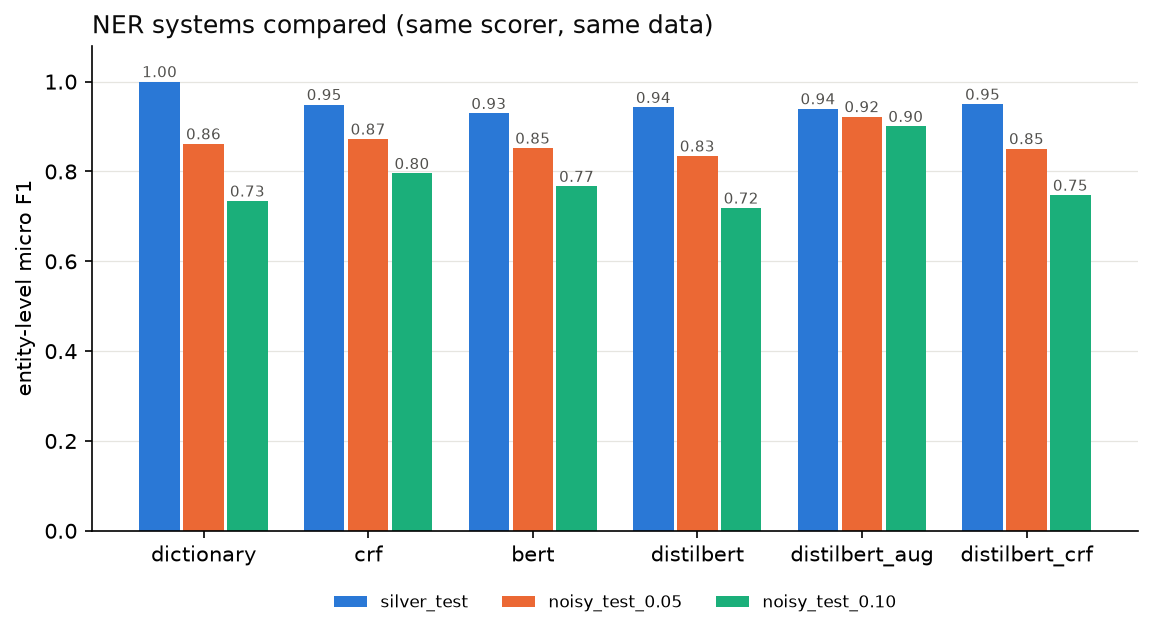

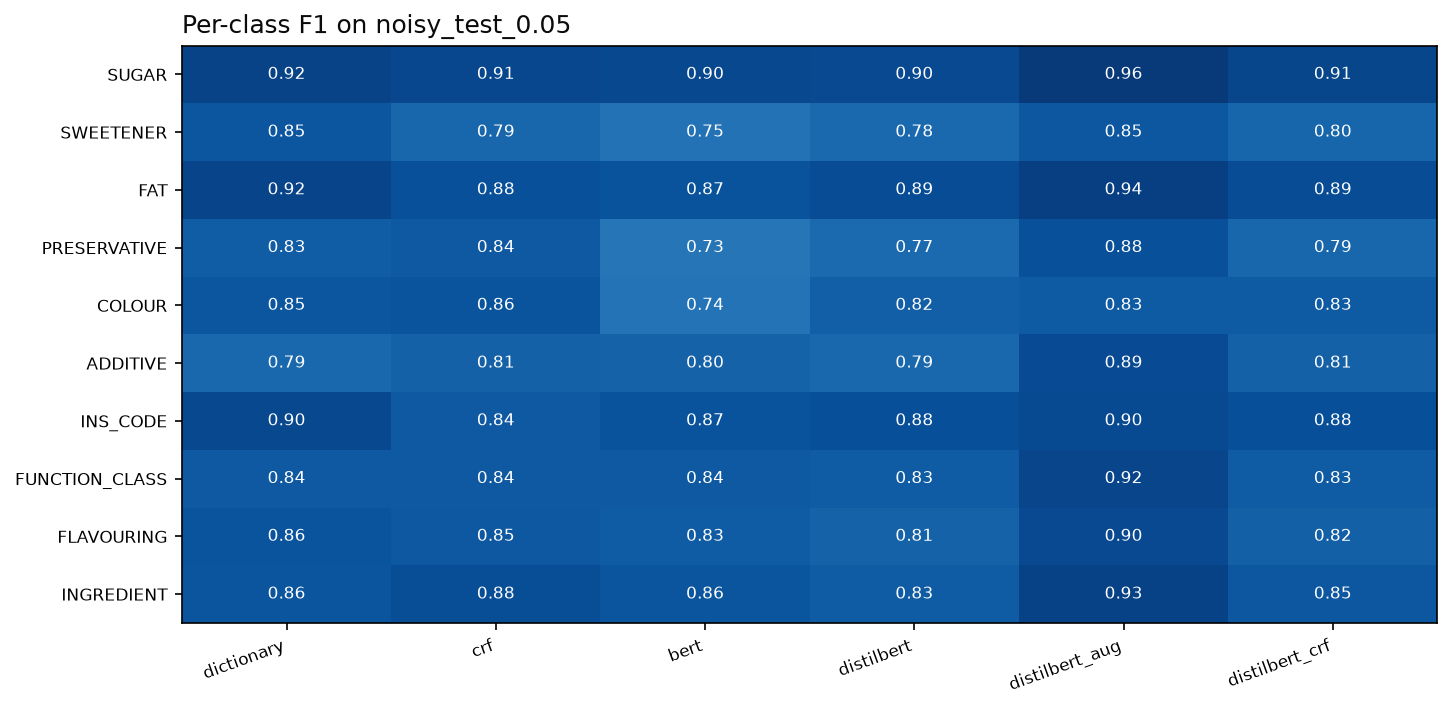

In [4]:
comparison = load("reports/model_comparison.json")
summary = pd.DataFrame(comparison["summary_f1"]).T
display(summary.round(3))
display(Image("reports/figures/12_model_comparison.png", width=900))
display(Image("reports/figures/13_per_class_f1_noisy.png", width=800))

How to read this:
* **silver_test.** The dictionary is 1.0 by construction, because silver labels *are* its output. A learned
  model close to 1.0 has learned the labelling policy and generalises it to unseen products.
* **noisy_test.** Same products with OCR-style character errors. The dictionary drops sharply because exact
  string matching fails. Models that learned from context hold up better, and the OCR-augmented model is
  trained for exactly this.
* **gold_test.** The real benchmark, available after the team's annotation.

In [5]:
details = comparison["details"]
best = max((m for m in details if m != "dictionary"), key=lambda m: details[m]["noisy_test_0.05"]["micro"]["f1"])
from src.evaluation.metrics import format_report
print("Best system on noisy text:", best)
display(Markdown(format_report(details[best]["noisy_test_0.05"], f"{best} on noisy_test_0.05")))
display(Markdown(format_report(details["dictionary"]["noisy_test_0.05"], "dictionary on noisy_test_0.05")))

Best system on noisy text: distilbert_aug


### distilbert_aug on noisy_test_0.05

| Class | Precision | Recall | F1 | Support |
|---|---:|---:|---:|---:|
| SUGAR | 0.960 | 0.969 | 0.965 | 1150 |
| SWEETENER | 0.879 | 0.820 | 0.849 | 89 |
| FAT | 0.922 | 0.959 | 0.940 | 950 |
| PRESERVATIVE | 0.861 | 0.890 | 0.875 | 146 |
| COLOUR | 0.808 | 0.863 | 0.834 | 219 |
| ADDITIVE | 0.849 | 0.938 | 0.891 | 1444 |
| INS_CODE | 0.832 | 0.971 | 0.896 | 697 |
| FUNCTION_CLASS | 0.888 | 0.949 | 0.917 | 1091 |
| FLAVOURING | 0.887 | 0.917 | 0.902 | 581 |
| INGREDIENT | 0.914 | 0.941 | 0.927 | 9760 |
| **overall (micro)** | **0.902** | **0.943** | **0.922** | 16127 |
| macro F1 | | | 0.900 | |
| partial match (micro) | 0.924 | 0.966 | 0.945 | |

### dictionary on noisy_test_0.05

| Class | Precision | Recall | F1 | Support |
|---|---:|---:|---:|---:|
| SUGAR | 0.984 | 0.867 | 0.922 | 1150 |
| SWEETENER | 1.000 | 0.742 | 0.852 | 89 |
| FAT | 0.982 | 0.864 | 0.919 | 950 |
| PRESERVATIVE | 0.981 | 0.712 | 0.825 | 146 |
| COLOUR | 0.988 | 0.753 | 0.855 | 219 |
| ADDITIVE | 0.956 | 0.668 | 0.787 | 1444 |
| INS_CODE | 0.967 | 0.849 | 0.904 | 697 |
| FUNCTION_CLASS | 0.975 | 0.742 | 0.843 | 1091 |
| FLAVOURING | 0.966 | 0.778 | 0.862 | 581 |
| INGREDIENT | 0.963 | 0.774 | 0.858 | 9760 |
| **overall (micro)** | **0.967** | **0.777** | **0.862** | 16127 |
| macro F1 | | | 0.863 | |
| partial match (micro) | 0.974 | 0.782 | 0.868 | |

### A5. Side by side on OCR-like text

In [6]:
from src.baseline.dictionary_ner import DictionaryNER
from src.ner.transformer_ner import TransformerTagger
model = TransformerTagger("models/ingredient-ner-distilbert")
rules = DictionaryNER()
examples = ["Sugar, lnvert syrup, ref1ned pa1m oil, Emu1sifier (INS 322), Acidity regu1ator (330), dextr0se",
            "WHEAT FLOUR SUGAR PALM OIL INVERT SUGAR SYRUP MILK SOLIDS EMULSIFIER 471 COLOUR 150d"]
for text in examples:
    print(text)
    for name, system in (("rules", rules), ("DistilBERT", model)):
        ents = system.predict(text)["entities"]
        print(f"  {name:10}", [(e["text"], e["label"]) for e in ents])

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 102/102 [00:00<00:00, 1899.64it/s]

Sugar, lnvert syrup, ref1ned pa1m oil, Emu1sifier (INS 322), Acidity regu1ator (330), dextr0se
  rules      [('Sugar', 'SUGAR'), ('lnvert syrup', 'SUGAR'), ('ref1ned pa1m oil', 'FAT'), ('INS 322', 'INS_CODE'), ('330', 'INS_CODE')]
  DistilBERT [('Sugar', 'SUGAR'), ('lnvert syrup', 'SUGAR'), ('ref1ned pa1m oil', 'FAT'), ('Emu1sifier', 'FUNCTION_CLASS'), ('INS 322', 'INS_CODE'), ('Acidity regu1ator', 'FUNCTION_CLASS'), ('330', 'INS_CODE'), ('dextr0se', 'SUGAR')]
WHEAT FLOUR SUGAR PALM OIL INVERT SUGAR SYRUP MILK SOLIDS EMULSIFIER 471 COLOUR 150d
  rules      [('EMULSIFIER', 'FUNCTION_CLASS'), ('471', 'INS_CODE'), ('COLOUR', 'FUNCTION_CLASS'), ('150d', 'INS_CODE')]
  DistilBERT [('SOLIDS', 'FUNCTION_CLASS'), ('EMULSIFIER', 'FUNCTION_CLASS'), ('471', 'INS_CODE'), ('COLOUR', 'FUNCTION_CLASS'), ('150d', 'INS_CODE')]


> **WHAT WE DID:** Trained DistilBERT/BERT token classifiers (plus a CRF head and an OCR-noise-augmented variant) on silver data and compared them with the rules and a feature-based CRF using one scorer.
>
> **WHY:** The dictionary is precise on clean text but brittle: OCR errors and missing commas break exact matching. A pretrained Transformer uses context, so it can still recognise 'lnvert syrup' as a sugar.
>
> **INPUT → OUTPUT:** silver training data → fine-tuned models + comparison tables
>
> **HOW TO EXPLAIN IT IN THE VIVA:** *"Weak supervision: the model is trained on rule labels and then has to generalise beyond the rules. We show this on noisy text where the rules fail, and the final benchmark is the human gold set."*

### A6. Error analysis of the models

In [7]:
rows = []
for f in sorted(Path("reports/error_analysis").glob("*_errors_noisy_test_0.05.csv")):
    e = pd.read_csv(f)
    rows.append({"system": f.name.split("_errors")[0], **e["error_type"].value_counts().to_dict(), "total": len(e)})
display(pd.DataFrame(rows).fillna(0).set_index("system"))
errors = pd.read_csv(f"reports/error_analysis/{best}_errors_noisy_test_0.05.csv")
display(errors.sample(min(12, len(errors)), random_state=0)[["text", "expected_entity", "expected_label", "predicted_entity", "predicted_label", "error_type", "tags"]])

,false_negative,false_positive,boundary_error,type_error,boundary_and_type,total
system,,,,,,
bert,1391,717,608,374,212,3302
crf,1712,867,244,371,103,3297
dictionary,3341,166,86,143,26,3762
distilbert_aug,251,824,322,213,137,1747
distilbert_crf,2217,551,470,267,125,3630
distilbert,2030,572,755,230,184,3771


,text,expected_entity,expected_label,predicted_entity,predicted_label,error_type,tags
1169,"Green olivcs, water, salt, lactic acid, sodium benzo",Green olivcs,INGREDIENT,olivcs,SUGAR,boundary_and_type,ocr_noise
1036,"ne 1-800 678708 Malohide Road, Cooloek, Dublin 5. www.cadbury.eo.uk Bes 13o62 107.5 g (5",NaN,NaN,Dublin 5,INGREDIENT,false_positive,NaN
988,", vitamin e (alpha tocopheryl acetote), thiamin manohitrate, riboflavln, vitamin b6 (pyridaxine hyd",NaN,NaN,thiamin manohitrate,INGREDIENT,false_positive,ocr_noise
1746,"unflower oil*, riee starch, rice flour, evaporated cone juice (cane sugar), inulin, egg whites, honey",evaporated cone juice,SUGAR,evaporated cone juice,INGREDIENT,type_error,NaN
1188,"NSW, 2748. THIS BAG IS SOLD BY WEIGHT, NOT VOLUME. AIR IS PACKAG IN EACH BAG TO CUSHION A",NOT VOLUME,INGREDIENT,NaN,NaN,false_negative,unknown_term
217,"For allergens, see ingredients in bold. Als0, may contain nuts, peahuts.",Als0,INGREDIENT,NaN,NaN,false_negative,compound|unknown_term
913,"ard flour, ground sesame seeds, spices (includes chili pepper {cohtains ethoxyquin}), natural flavor.",includes chili pepper,INGREDIENT,chili pepper,INGREDIENT,boundary_error,compound
141,"hite Vineqar, Organic Garlic, Sea Salt, Organic Lemon Oil, Orqanic Lemon Peel, Turmeric, Citric A",Organic Lemon Oil,FLAVOURING,Organic Lemon Oil,FAT,type_error,NaN
1660,a saucepan of hot (not boiling) water. Heat gently for about 5 mihutes. Do not boiI. STORAGE: Refrigerate,Heat gently for about 5 mihutes,INGREDIENT,gently,INGREDIENT,boundary_error,ocr_noise
175,"). Svgar, Stabiliser, Salt, Emulslfier [E471] Allergen: Contains Peonuts, 5oya.",NaN,NaN,E471,INS_CODE,false_positive,ins_code_variant|compound


### A7. Exported Hugging Face model

In [8]:
print(Path("models/ingredient-ner-distilbert/README.md").read_text()[:1500])
from transformers import pipeline
hf = pipeline("token-classification", model="models/ingredient-ner-distilbert", aggregation_strategy="first")
pd.DataFrame(hf("Sugar, glucose syrup, acidity regulator (INS 330), palm oil"))[["word", "entity_group", "score"]]

# ingredient-ner-distilbert

DistilBERT (distilbert-base-uncased) fine-tuned for named-entity recognition on food ingredient lists.
Part of the *Ingredient Scanner* student project. Training run: `distilbert_aug`.

## Labels
SUGAR, SWEETENER, FAT, PRESERVATIVE, COLOUR, ADDITIVE, INS_CODE, FUNCTION_CLASS, FLAVOURING, INGREDIENT (BIO scheme,
21 tags; see `config.json` and `reports/entity_schema.md`).

## Training data
Silver (rule-generated) labels for Open Food Facts ingredient lists (English; India, UK/Ireland, North America,
other English-speaking markets), seeded subsample of 8000 sentences,
2 epochs, learning rate 5e-05, OCR-noise augmentation:
True. Best validation F1 (silver): 0.9444.

## Evaluation (entity-level micro F1, strict)
| Evaluation set | F1 |
|---|---:|
| silver_test | 0.940 |
| noisy_test_0.05 | 0.922 |
| noisy_test_0.10 | 0.900 |

`silver_test` uses rule-made labels; `noisy_test_*` adds OCR-style character noise to the same texts.
Human-verified gold results appear i

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 102/102 [00:00<00:00, 3943.94it/s]

,word,entity_group,score
0,sugar,SUGAR,0.997090
1,glucose syrup,SUGAR,0.995554
2,acidity regulator,FUNCTION_CLASS,0.991323
3,ins 330,INS_CODE,0.991955
4,palm oil,FAT,0.987740


## Part B: Person 3, knowledge base, OCR, entity linking, app

### B1. Knowledge base
Built by `src/kb/build_knowledge_base.py` from the Open Food Facts taxonomies (ODbL): descriptions only, no health ratings.

In [9]:
kb = Path("data/knowledge_base")
additives = pd.read_csv(kb / "additives.csv", dtype=str).fillna("")
print({f.name: len(pd.read_csv(f)) for f in sorted(kb.glob("*.csv"))})
display(additives[additives["ins_number"].isin(["330", "211", "102", "471", "955"])][["kb_id", "name", "ner_label", "function_classes_text", "function_description"]])
nutrition = kb / "products_nutrition.csv"
if nutrition.exists():
    display(pd.read_csv(nutrition, dtype={"product_id": str}).dropna(subset=["sugars_100g"]).head(5))

{'additives.csv': 731, 'categories.csv': 10, 'function_classes.csv': 53, 'ingredient_terms.csv': 1556, 'products_nutrition.csv': 22355}


,kb_id,name,ner_label,function_classes_text,function_description
17,INS:102,Tartrazine,COLOUR,Colour,"Colours are substances which add or restore colour in a food, and include natural constituents of foods an..."
196,INS:211,Sodium benzoate,PRESERVATIVE,Preservative,Preservatives are substances which prolong the shelf-life of foods by protecting them against deterioratio...
293,INS:330,Citric acid,ADDITIVE,"Antioxidant, Sequestrant",Antioxidants are substances which prolong the shelf-life of foods by protecting them against deterioration...
481,INS:471,Mono- and diglycerides of fatty acids,ADDITIVE,"Emulsifier, Stabiliser",Emulsifiers are substances which make it possible to form or maintain a homogenous mixture of two or more ...
707,INS:955,Sucralose,SWEETENER,Sweetener,Sweeteners are substances used to impart a sweet taste to foods or in table-top sweeteners.


,product_id,product_name,brands,country_group,main_category,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g
23,00001101,Organic Goat Feed - Mash,"Inewa,Scratch And Peck Feeds",india,NaN,471.0,25.0,11.0,55.0,24.0,1.5,5.8,NaN
27,00001247,Shake Mix Vanilla Flavour,Herbalife,india,Dietary supplements,376.0,7.2,1.6,42.0,29.6,12.0,36.0,1.23
32,0000150484118,Honduran king prawns M&S,NaN,uk_ireland,Cooked Prawns,113.0,0.6,0.4,3.1,0.4,1.1,23.3,1.43
37,0000200010400,Supreme Prawn Cocktail,Walkers,uk_ireland,Flavoured potato crisps,508.0,28.8,2.4,52.0,2.4,4.4,6.0,0.63
38,00002171,Organic Vegan Protein Shake Mix,Earth Chimp,uk_ireland,Protein powders,120.0,2.0,0.0,11.0,0.0,5.0,20.0,0.60


### B2. OCR on a real packet photo

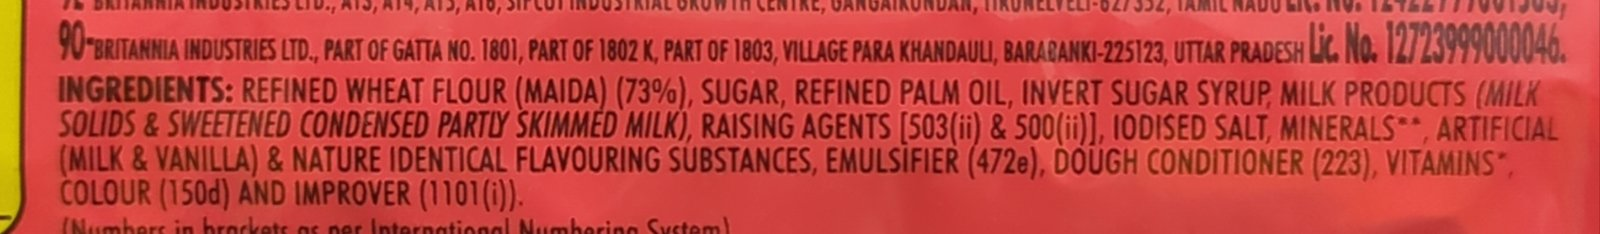

OCR text (first 600 chars):
 "1
INGREDIENTS: REFINED WHEAT FLOUR (MAIDA) (73%) SUGAR, REFINED PALM OIL, INVERT SUGAR SYRUP MILk products (MIlk
ARTIFICIAL
(Milk & VANILLA) & NATURE UDENTICAL FLAVOURING SUBSTANCES, EMULSIfIER (472e) , DOUGH CONDITIONER (223), VITAMINS 
COLOUR (I5Od) AND IMPROVER (11O0T ()}:

Section found by: keyword
REFINED WHEAT FLOUR (MAIDA) (73%) SUGAR, REFINED PALM OIL, INVERT SUGAR SYRUP MILk products (MIlk ARTIFICIAL (Milk & VANILLA) & NATURE UDENTICAL FLAVOURING SUBSTANCES, EMULSIfIER (472e) , DOUGH CONDITIONER (223), VITAMINS  COLOUR (150d) AND IMPROVER (11O0T ()}


In [10]:
from src.ocr.ocr_pipeline import read_image
from src.ocr.ocr_cleanup import fix_additive_codes
from src.ocr.section_extraction import extract_ingredients_section
photo = "data/images/packets/8901063162518.jpg"
display(Image(photo, width=420))
ocr = read_image(photo)
print("OCR text (first 600 chars):\n", ocr["text"][:600])
cleaned = fix_additive_codes(ocr["text"])
section = extract_ingredients_section(cleaned)
print("\nSection found by:", section["method"]); print(section["text"])

> **WHAT WE DID:** EasyOCR (CRAFT detector + CRNN recogniser) with OpenCV pre-processing, reading-order line grouping, automatic rotation, a targeted fix for OCR errors in additive codes ('I5Od' -> '150d'), and extraction of the ingredients section.
>
> **WHY:** A packet photo contains much more than the ingredient list, and OCR confuses digits with letters exactly where additive codes are.
>
> **INPUT → OUTPUT:** photo → ingredient-list text
>
> **HOW TO EXPLAIN IT IN THE VIVA:** *"The code clean-up only touches code-like tokens in brackets or after INS/E, so it cannot invent ingredients."*

### B3. Entity linking

In [11]:
from src.kb.entity_linking import get_linker
linker = get_linker()
tests = [{"text": "INS 330", "label": "INS_CODE"}, {"text": "503(ii)", "label": "INS_CODE"}, {"text": "soy lecithin", "label": "ADDITIVE"},
         {"text": "potasium sorbate", "label": "PRESERVATIVE"}, {"text": "Acidity regulator", "label": "FUNCTION_CLASS"},
         {"text": "glucose syrup", "label": "SUGAR"}]
pd.DataFrame([{**t, **{k: v for k, v in linker.link(t).items() if k in ("link_method", "kb_id", "canonical_name", "function")}} for t in tests])

,text,label,kb_id,canonical_name,function,link_method
0,INS 330,INS_CODE,INS:330,Citric acid,"Antioxidant, Sequestrant",ins_number
1,503(ii),INS_CODE,INS:503ii,Ammonium hydrogen carbonate,,ins_number
2,soy lecithin,ADDITIVE,INS:322,Lecithins,"Antioxidant, Emulsifier",exact_name
3,potasium sorbate,PRESERVATIVE,INS:202,Potassium sorbate,Preservative,fuzzy_name
4,Acidity regulator,FUNCTION_CLASS,CLASS:acidity-regulator,Acidity regulator,Acidity regulator,exact_name
5,glucose syrup,SUGAR,TERM:glucose syrup,glucose syrup,,exact_name


### B4. The complete pipeline: photo in, result out

In [12]:
from src.app.scanner import IngredientScanner
scanner = IngredientScanner("auto")
result = scanner.scan_image(photo)
print("NER model:", result["ner_model"], "| OCR + analysis time:", result["ocr"]["seconds"], "s")
display(pd.DataFrame(result["entities"])[["text", "label", "canonical_name", "function", "link_method"]])
print(json.dumps(result["summary"], indent=1))
print(result["disclaimer"])

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 102/102 [00:00<00:00, 2163.12it/s]

NER model: ingredient-ner-distilbert | OCR + analysis time: 3.0 s


,text,label,canonical_name,function,link_method
0,REFINED WHEAT FLOUR,INGREDIENT,,,category
1,MAIDA,INGREDIENT,,,category
2,SUGAR,SUGAR,sugar,,exact_name
3,REFINED PALM OIL,FAT,,,category
4,INVERT SUGAR SYRUP MILk products,INGREDIENT,,,category
5,MIlk ARTIFICIAL,INGREDIENT,,,category
6,Milk & VANILLA,INGREDIENT,,,category
7,NATURE UDENTICAL FLAVOURING SUBSTANCES,FLAVOURING,,,category
8,EMULSIfIER,FUNCTION_CLASS,Emulsifier,Emulsifier,exact_name
9,472e,INS_CODE,Mono- and diacetyltartaric acid esters of mono- and diglycerides of fatty acids,"Emulsifier, Sequestrant, Stabiliser",ins_number


{
 "counts": {
  "SUGAR": 1,
  "SWEETENER": 0,
  "FAT": 1,
  "PRESERVATIVE": 1,
  "COLOUR": 1,
  "ADDITIVE": 2,
  "FLAVOURING": 1,
  "INGREDIENT": 5
 },
 "groups": {
  "SUGAR": [
   "SUGAR"
  ],
  "SWEETENER": [],
  "FAT": [
   "REFINED PALM OIL"
  ],
  "PRESERVATIVE": [
   "223 (Sodium metabisulphite)"
  ],
  "COLOUR": [
   "150d (Sulphite ammonia caramel)"
  ],
  "ADDITIVE": [
   "472e (Mono- and diacetyltartaric acid esters of mono- and diglycerides of fatty acids)",
   "11O0T"
  ],
  "FLAVOURING": [
   "NATURE UDENTICAL FLAVOURING SUBSTANCES"
  ],
  "INGREDIENT": [
   "REFINED WHEAT FLOUR",
   "MAIDA",
   "INVERT SUGAR SYRUP MILk products",
   "MIlk ARTIFICIAL",
   "Milk & VANILLA"
  ]
 },
 "hidden": {
  "sugars_under_other_names": [],
  "fats_under_other_names": [],
  "additives_written_as_codes": [
   "472e",
   "223",
   "150d",
   "11O0T"
  ]
 }
}
This tool identifies ingredients and explains what they are and what they are used for. It does not assess whether a product is heal

### B5. End-to-end evaluation on 60 real photos (held-out test products)

In [13]:
e2e = load("reports/ocr_end_to_end.json")
print("Photos:", e2e["photos"]); display(e2e["ocr"])
display(pd.DataFrame({s: {"entities exact F1": v["entities_exact"]["f1"], "entities fuzzy F1": v["entities_fuzzy"]["f1"],
                          "additive numbers P": v["additive_numbers"]["precision"], "additive numbers R": v["additive_numbers"]["recall"],
                          "additive numbers F1": v["additive_numbers"]["f1"]} for s, v in e2e["systems"].items()}).T)

Photos: 60


{'median_cer_section': 0.638,
 'median_word_recall_full_ocr': 0.72,
 'median_word_recall_section': 0.687,
 'photos_readable (full-text word recall >= 0.5)': 42,
 'section_methods': {'full_text': 19, 'keyword': 36, 'comma_density': 5},
 'by_market_median_word_recall_full_ocr': {'india': 0.728,
  'north_america': 0.893,
  'other_english': 0.494,
  'uk_ireland': 0.613}}

,entities exact F1,entities fuzzy F1,additive numbers P,additive numbers R,additive numbers F1
dictionary,0.485,0.507,0.957,0.412,0.576
crf,0.462,0.498,0.934,0.444,0.602
bert,0.464,0.501,0.959,0.444,0.607
distilbert,0.477,0.507,0.959,0.444,0.607
distilbert_aug,0.465,0.515,0.974,0.475,0.639
distilbert_crf,0.476,0.504,0.959,0.438,0.601


* **CER** = character error rate of the extracted section against the product's typed ingredient list.
  The reference was typed by Open Food Facts contributors and may differ slightly from the photo.
* **Entity F1** compares (label, text) bags. *Fuzzy* accepts small spelling differences.
* **Additive numbers**: which additives the app identifies (through codes or names), compared with the reference.

### B6. The app

```bash
streamlit run src/app/streamlit_app.py
```

Tabs: **Camera** (take a picture), **Upload photo**, **Example packets** (the 60 real photos), **Paste text**.
Deployment: `Dockerfile` and `docs/DEPLOYMENT.md` (Hugging Face Spaces recommended).

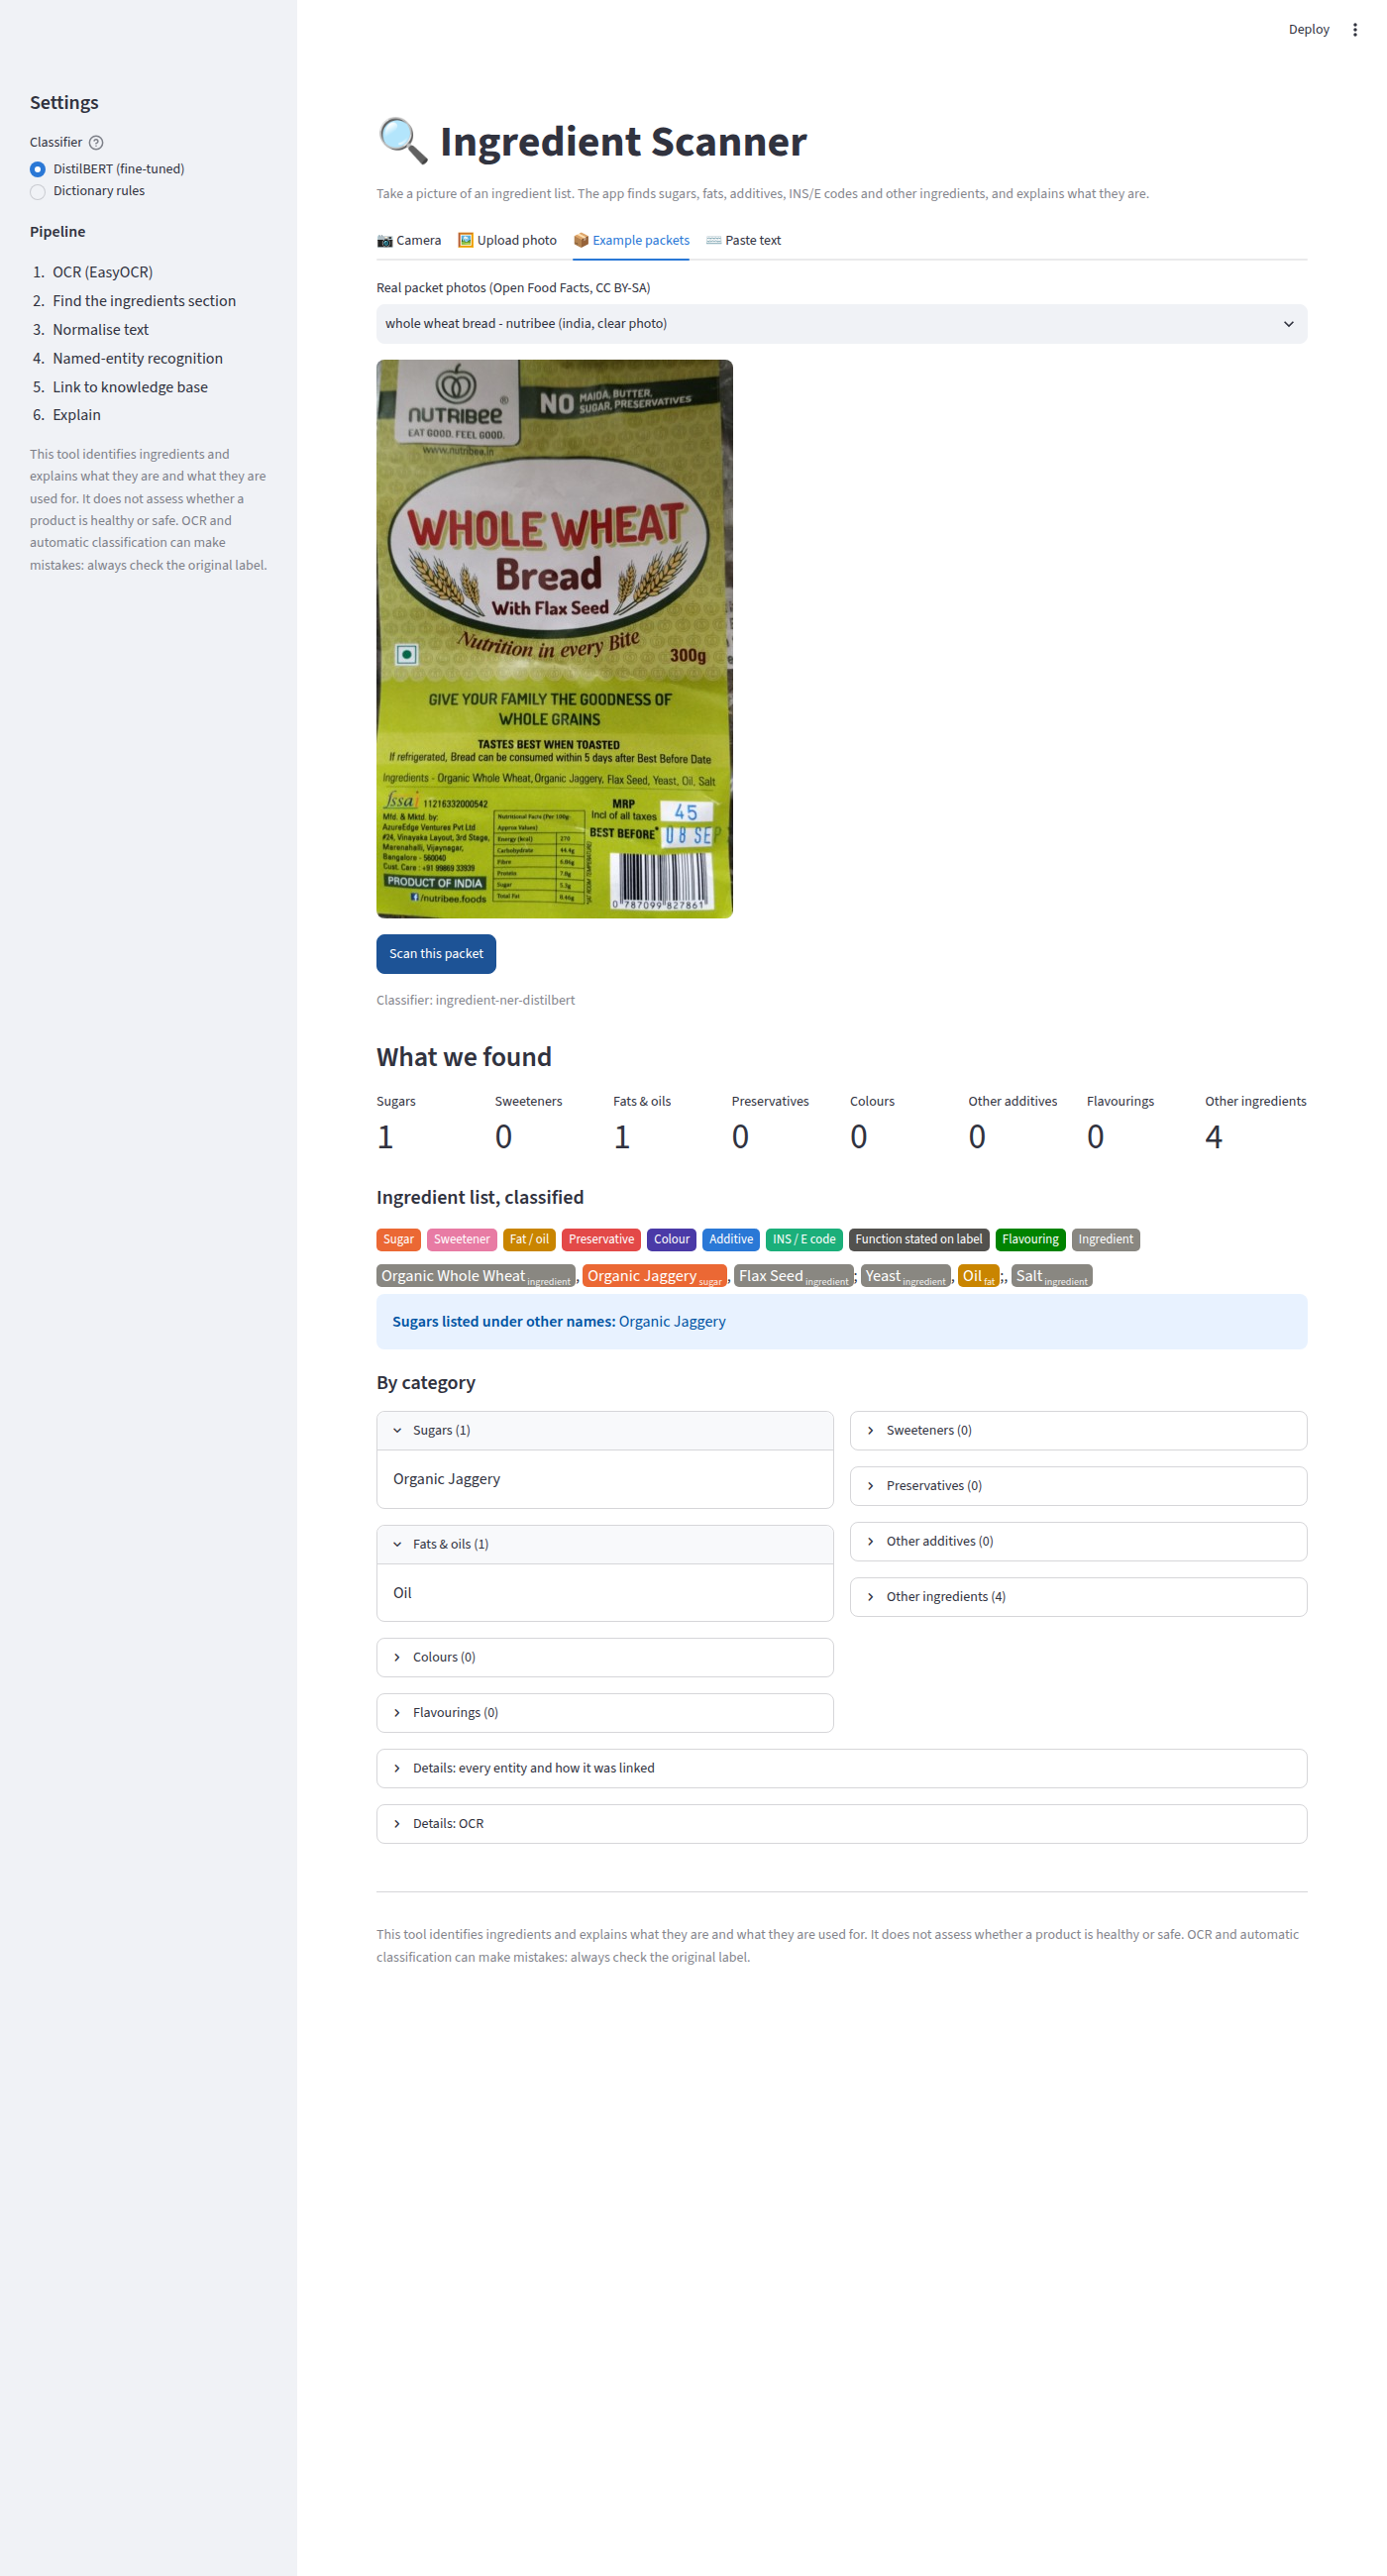

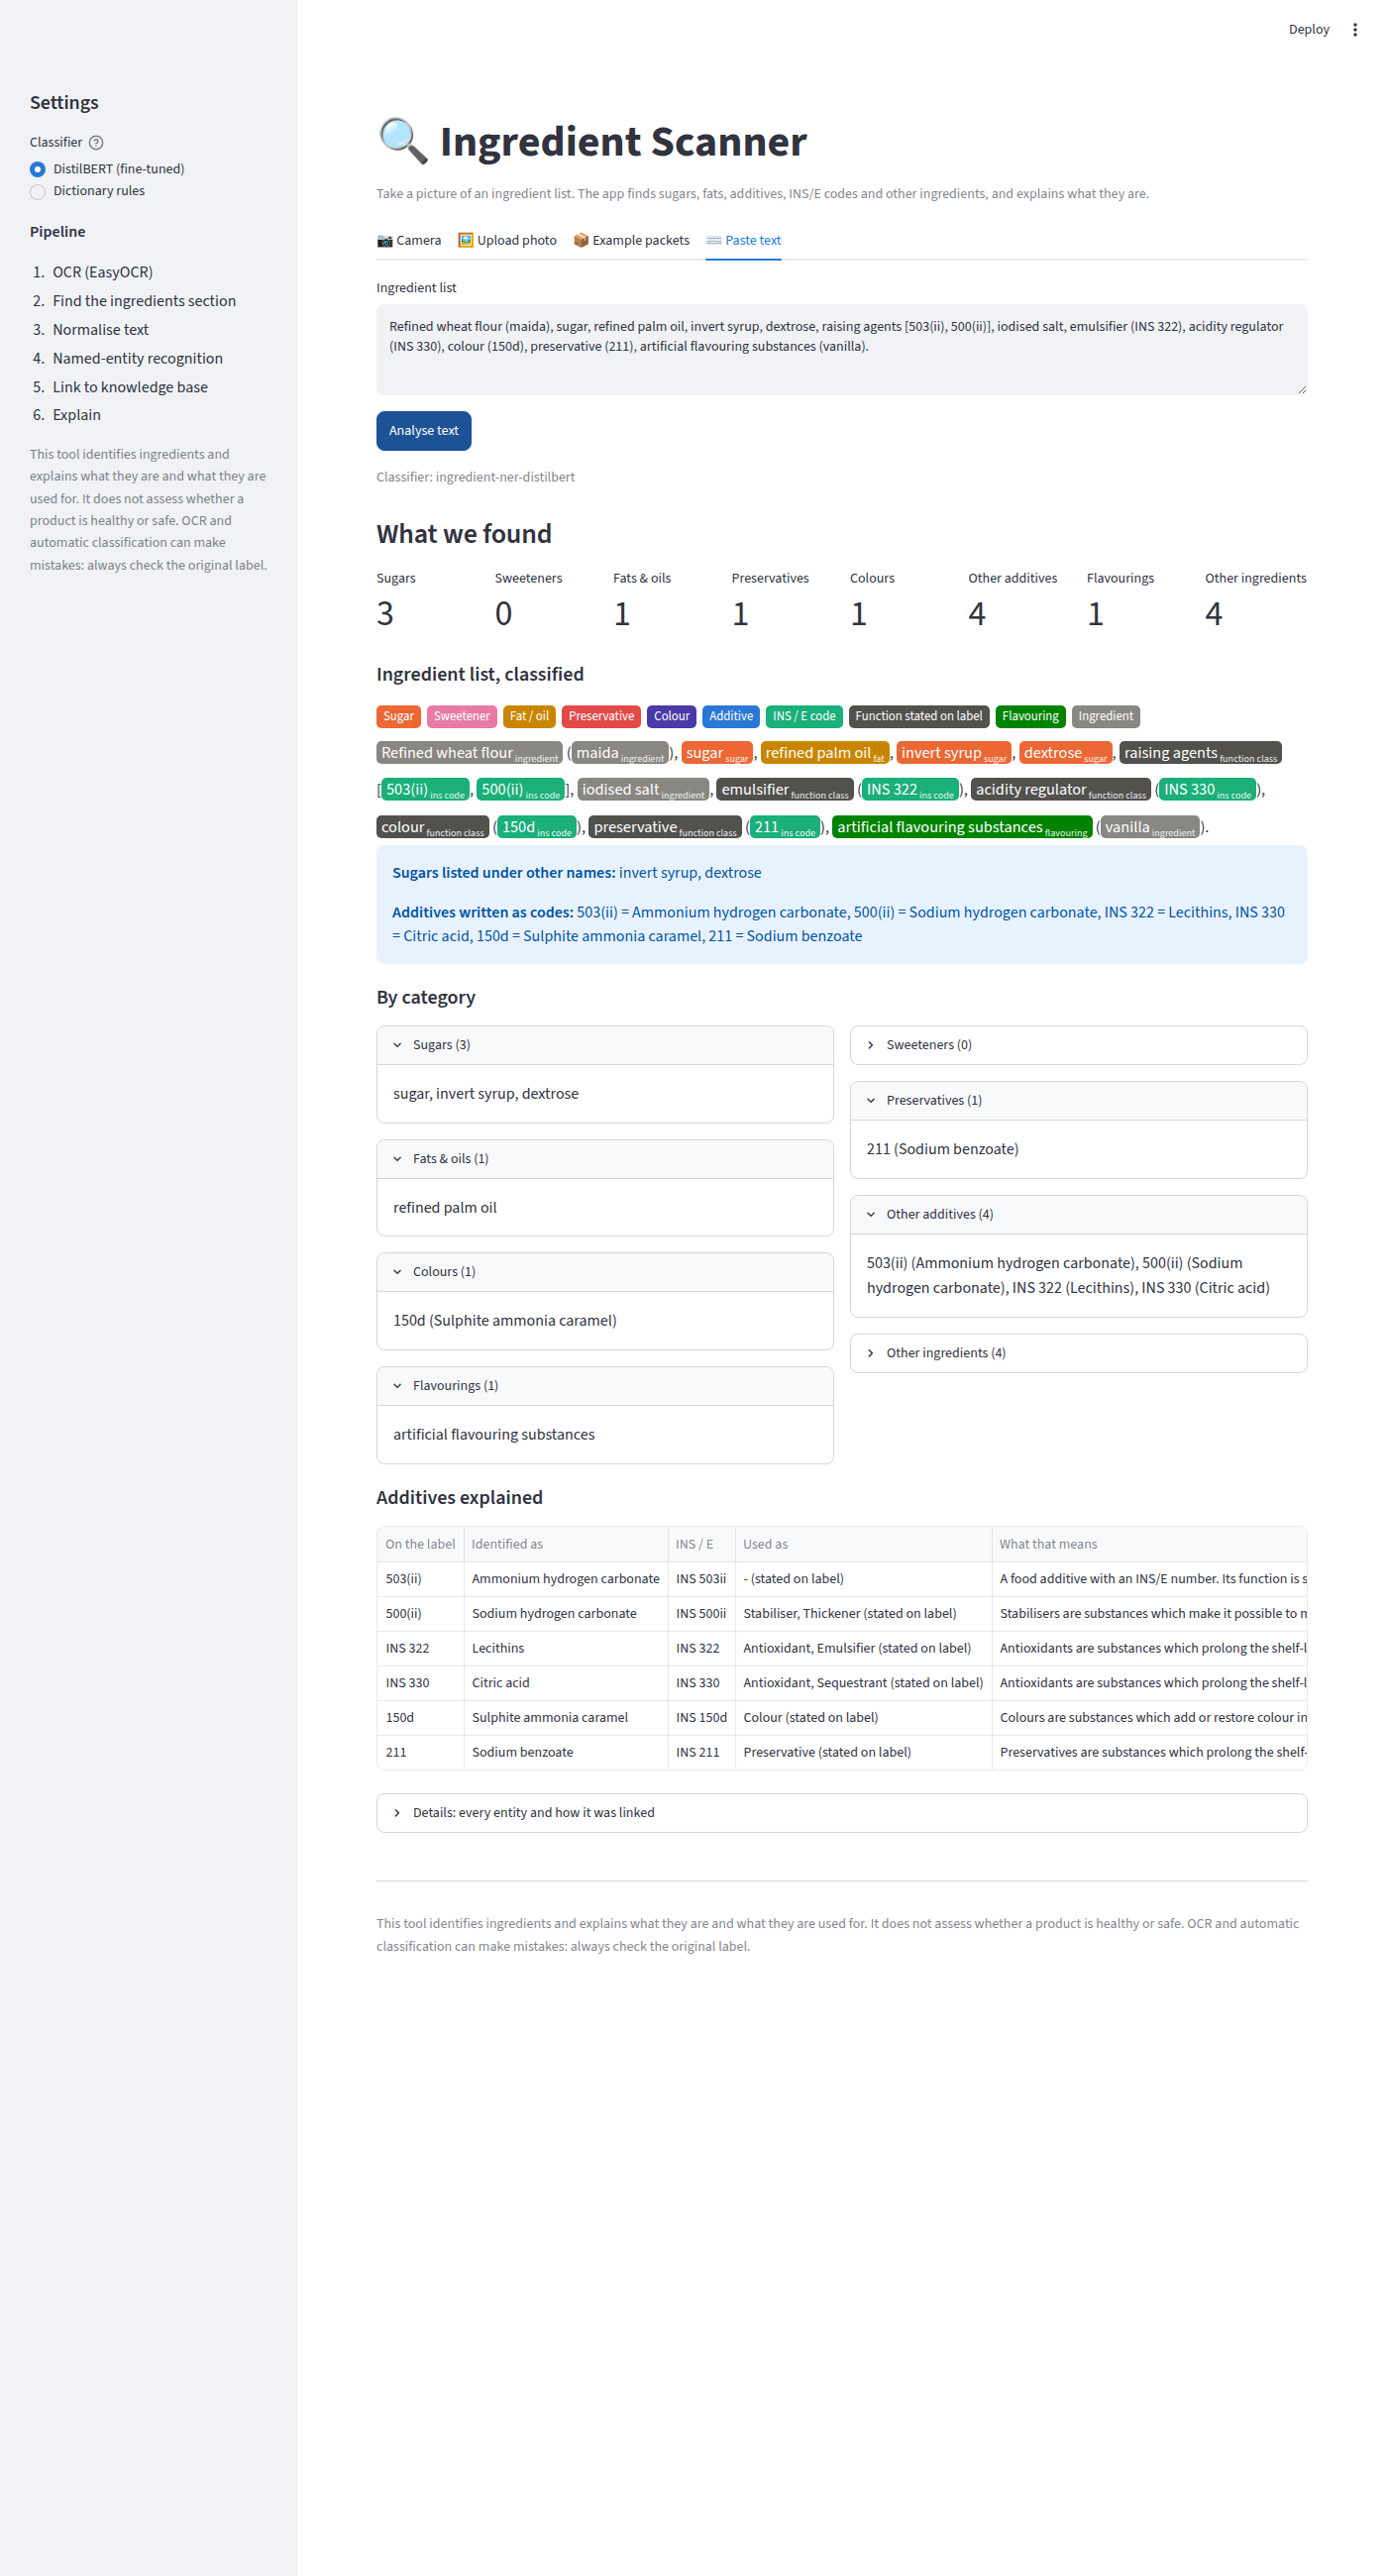

In [14]:
for shot in sorted(Path("reports/figures").glob("app_*.png")):
    display(Image(str(shot), width=900))

## Limitations

* **Silver supervision.** Models learn the rules' policy, including some of their mistakes. Final claims
  need the human gold test set.
* **CPU training.** 8,000 sentences, 1–2 epochs. More data or epochs would likely help.
* **OCR.** Curved, glossy or small print causes errors. The photo reference text is crowd-typed.
  Section extraction fails when "Ingredients" is not printed or not recognised.
* **Missing separators.** When OCR loses all commas (second example in A5), neither the rules nor the
  model split the ingredients correctly.
* **English only.** Labels in other languages or scripts are not handled.
* **No health claims.** The app identifies and explains ingredients; it does not rate products.